In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, precision_recall_curve

### Carichiamo il dataset e visualizziamo le caratteristiche

Il dataset contiene informazioni su circa 45000 richieste di prestito a una banca, relativamente allo status del richiedente, all'ammontare e al tipo di prestito, e se il prestito è stato accettato o meno

In [3]:
data = pd.read_csv("./dataset/loan_data.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

**Data.describe()** mi dà informazioni riguardanti alle statistiche sulle varie feature del dataset. Alcune feature hanno osservazioni probabilmente errate (età di 144 anni, o esperienza lavorativa di 125 anni)

In [5]:
data.describe() 

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [6]:
print(len(data))
data = data[data['person_age'] <= 90] #OCCUPIAMOCI DI OSSERVAZIONI "STRANE" COME ETA' DI 144 ANNI
print(len(data))

45000
44992


In [7]:
data.duplicated().sum() #Nessun duplicato

0

### Combino person age e person employment experience per ricavare una nuova feature, ovvero employment ratio

Employment ratio varierà da 0 a 1. Quanto più è alto, più quella persona avrà lavorato durante la propria vita

In [8]:
data['employment_ratio'] = data['person_emp_exp'] / data['person_age']

data = data.drop(['person_emp_exp'], axis=1)

In [9]:
data.describe()

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,employment_ratio
count,44992.000000,4.499200e+04,44992.000000,44992.000000,44992.000000,44992.000000,44992.000000,44992.000000,44992.000000
mean,27.746955,7.990956e+04,9583.245288,11.006448,0.139735,5.866087,632.582592,0.222262,0.167260
std,5.901543,6.332239e+04,6314.856103,2.979019,0.087207,3.875930,50.398623,0.415771,0.144897
min,20.000000,8.000000e+03,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,4.719725e+04,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.041667
50%,26.000000,6.704600e+04,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000,0.148148
75%,30.000000,9.577900e+04,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000,0.264706
max,84.000000,2.448661e+06,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000,0.775000


### Separo le feature (X) dalla variabile target (y)

In [10]:
X = data.drop('loan_status', axis=1)
y = data['loan_status']


In [11]:
# Dividiamo feature numeriche da feature categoriali
num_features = ['person_age','person_income', 'employment_ratio', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'] # Solo quelle continue/discrete vere
cat_features = ['person_gender', 'person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file'] # Quelle testuali da codificare


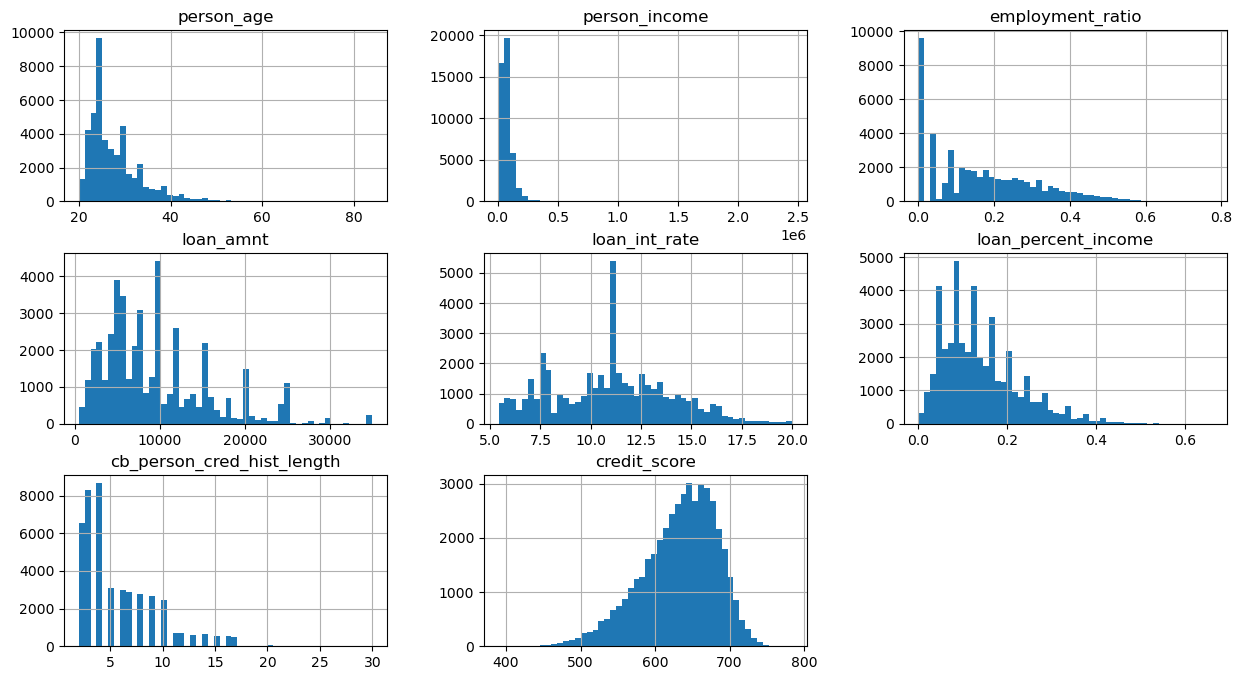

In [12]:

data[num_features].hist(bins=50, figsize=(15, 8))   
plt.show()

 Alcune feature hanno distribuzione piuttosto asimmetrica (molti outliers). Prima dello scaling, converrebbe fare una trasformazione logaritmica

In [13]:
data[num_features].skew()  

person_age                    1.887917
person_income                 9.695046
employment_ratio              0.711302
loan_amnt                     1.179750
loan_int_rate                 0.213913
loan_percent_income           1.034904
cb_person_cred_hist_length    1.627752
credit_score                 -0.615776
dtype: float64

In [14]:
#DIVIDO LE FEATURE NUMERICHE TRA QUELLE CHE DEVONO SUBIRE TRASFORMAZIONE LOGARITMICA E QUELLE CHE SONO GIA' OK

num_skewed = ['person_income', 'person_age', 'cb_person_cred_hist_length', 'loan_amnt', 'loan_percent_income']
num_normal = ['employment_ratio', 'loan_int_rate', 'credit_score']

### Ora preparo le operazioni di preprocessing. Utilizzo StandardScaler sulle feature numeriche e OneHotEncoder per le categoriali


In [15]:
#Definiamo il custom transformer

log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

# Pipeline per le asimmetriche (Log + Scaler)
skewed_pipeline = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())  #il risultato lo passo allo scaler
])

# ColumnTransformer Finale
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', skewed_pipeline, num_skewed),
        ('normal', StandardScaler(), num_normal),
        ('cat', OneHotEncoder(), cat_features) 
    ]
)

### Prima del preprocessing effettivo, effettuo lo split in train set (80%) e test set (20%)

**stratify=y** serve a garantire che la proporzione delle classi della variabile target rimanga la stessa sia nel set di addestramento (train set) sia nel set di test (test set).

**random_state** garantisce che la separazione delle righe sarà identica a ogni singola esecuzione del codice. (seme che viene usato per lo split)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(35993, 13)
(8999, 13)
(35993,)
(8999,)


Qui avviene effettivamente il preprocessing. Applico **fit_transform** sul train set. In questo modo prima fit() calcola i parametri necessari (ad esempio media e dev. standard per lo standard scaler), e poi usa quei parametri per la trasformazione con transform().

Sul test set, invece, uso solo transform in quanto i parametri per la standardizzazione vengono presi da X_train

In [17]:

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Modelli
I modelli che utilizzo sono Logistic Regression e RandomForestClassifier

In [24]:
#Logistic Regression
log_reg = LogisticRegression(random_state=42)

In [29]:
#Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [30, 40, 50],
    'min_samples_leaf': [10, 15, 20],
}

grid_search = GridSearchCV(   #grid search per trovare i migliori iperparametri
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1',             # l'obiettivo è l' F1-SCORE 
    cv=3,                     # 3-fold Cross-Validation 
    n_jobs=-1,                # Usa tutti i core della CPU disponibili per velocizzare il calcolo
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Migliori iperparametri:")
print(grid_search.best_params_)


Migliori iperparametri:
{'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 100}


In [30]:

y_train_probs_lr = cross_val_predict(log_reg, X_train, y_train, cv=3, method='predict_proba')[:, 1]

y_train_probs_rf = cross_val_predict(best_model, X_train, y_train, cv=3, method='predict_proba')[:, 1]

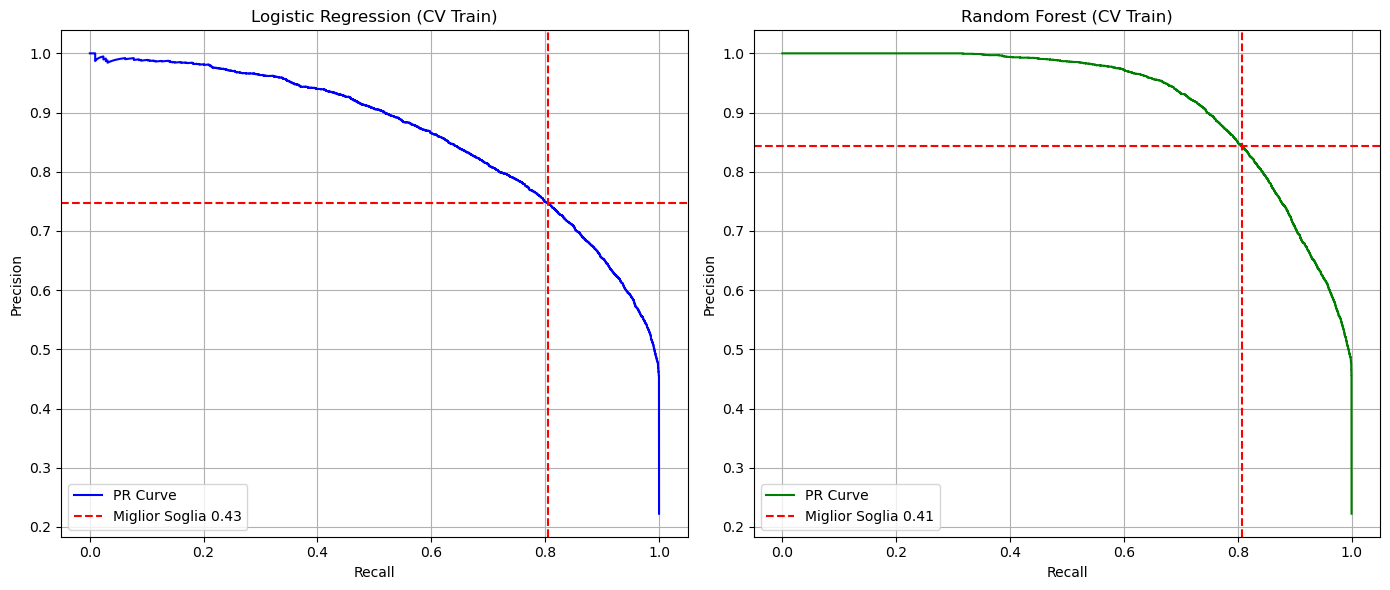

Soglia Max F1 (LR): 0.426
Soglia Max F1 (RF): 0.413


In [31]:
# Metriche per Logistic Regression
prec_lr, rec_lr, thresh_lr = precision_recall_curve(y_train, y_train_probs_lr)
f1_lr = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr) 
best_idx_lr = np.argmax(f1_lr)  #restituisce l'indice del valore più grande.
best_thresh_lr = thresh_lr[best_idx_lr]  #uso l'indice per recuperare la rispettiva soglia


# Metriche per Random Forest
prec_rf, rec_rf, thresh_rf = precision_recall_curve(y_train, y_train_probs_rf)
f1_rf = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf)
best_idx_rf = np.argmax(f1_rf)
best_thresh_rf = thresh_rf[best_idx_rf]


#  Disegno delle PR Curve affiancate
# =======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Logistic Regression
axes[0].plot(rec_lr[:-1], prec_lr[:-1], color='blue', label='PR Curve')
axes[0].axvline(x=rec_lr[best_idx_lr], color='red', linestyle='--', label=f'Miglior Soglia {best_thresh_lr:.2f}')
axes[0].axhline(y=prec_lr[best_idx_lr], color='red', linestyle='--')
axes[0].set_title('Logistic Regression (CV Train)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].grid(True)

# Grafico 2: Random Forest
axes[1].plot(rec_rf[:-1], prec_rf[:-1], color='green', label='PR Curve')
axes[1].axvline(x=rec_rf[best_idx_rf], color='red', linestyle='--', label=f'Miglior Soglia {best_thresh_rf:.2f}')
axes[1].axhline(y=prec_rf[best_idx_rf], color='red', linestyle='--')
axes[1].set_title('Random Forest (CV Train)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Stampiamo un riepilogo delle metriche attese
print(f"Soglia Max F1 (LR): {best_thresh_lr:.3f}")
print(f"Soglia Max F1 (RF): {best_thresh_rf:.3f}")

In [32]:
# Verdetto Definitivo sul Test Set
# modelli addestrati su tutto il Train

log_reg.fit(X_train, y_train)
best_model.fit(X_train, y_train)

# Estraggo le probabilità dal Test Set
y_test_probs_lr = log_reg.predict_proba(X_test)[:, 1]
y_test_probs_rf = best_model.predict_proba(X_test)[:, 1]

# Applico le soglie personalizzate trovate prima
y_test_pred_lr = (y_test_probs_lr >= best_thresh_lr)
y_test_pred_rf = (y_test_probs_rf >= best_thresh_rf)

# report finali
print("--- RISULTATI TEST SET: LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_test_pred_lr, target_names=['Respinto','Accettato']))

print("\n--- RISULTATI TEST SET: RANDOM FOREST ---")
print(classification_report(y_test, y_test_pred_rf, target_names=['Respinto','Accettato']))

--- RISULTATI TEST SET: LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

    Respinto       0.94      0.92      0.93      6999
   Accettato       0.75      0.81      0.78      2000

    accuracy                           0.90      8999
   macro avg       0.84      0.86      0.85      8999
weighted avg       0.90      0.90      0.90      8999


--- RISULTATI TEST SET: RANDOM FOREST ---
              precision    recall  f1-score   support

    Respinto       0.95      0.96      0.95      6999
   Accettato       0.85      0.81      0.83      2000

    accuracy                           0.92      8999
   macro avg       0.90      0.88      0.89      8999
weighted avg       0.92      0.92      0.92      8999



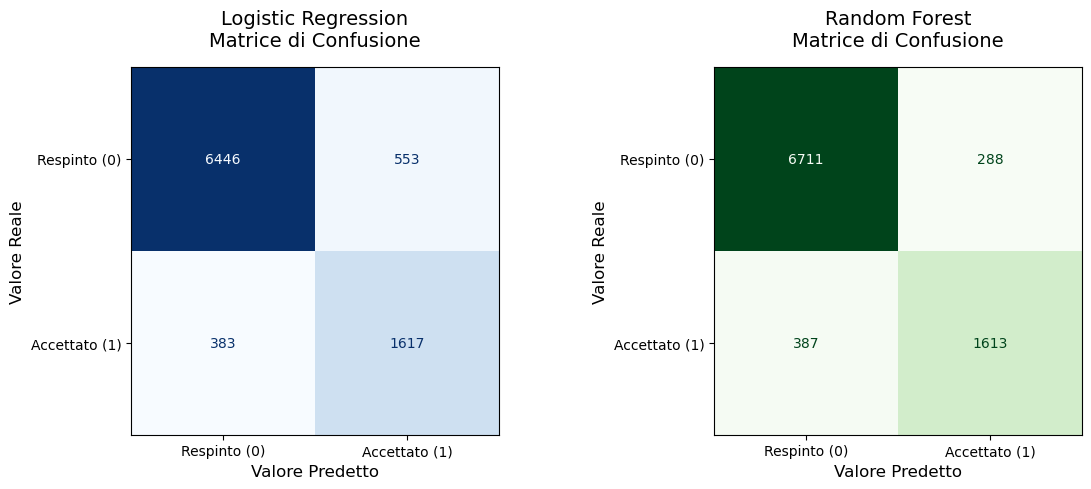

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Creazione dell'area di disegno: 1 riga, 2 colonne
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GRAFICO 1: LOGISTIC REGRESSION ---
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_test_pred_lr, 
    display_labels=['Respinto (0)', 'Accettato (1)'], 
    cmap='Blues', 
    colorbar=False, 
    ax=axes[0]
)
axes[0].set_title('Logistic Regression\nMatrice di Confusione', fontsize=14, pad=15)
axes[0].set_xlabel('Valore Predetto', fontsize=12)
axes[0].set_ylabel('Valore Reale', fontsize=12)

# --- GRAFICO 2: RANDOM FOREST ---
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_test_pred_rf, 
    display_labels=['Respinto (0)', 'Accettato (1)'], 
    cmap='Greens', 
    colorbar=False, 
    ax=axes[1]
)
axes[1].set_title('Random Forest\nMatrice di Confusione', fontsize=14, pad=15)
axes[1].set_xlabel('Valore Predetto', fontsize=12)
axes[1].set_ylabel('Valore Reale', fontsize=12)

# Ottimizza gli spazi e mostra il grafico
plt.tight_layout()
plt.show()